## 판다스 (pandas)

In [371]:
import pandas as pd

### 딕셔너리에서 데이터프레임 변경

In [372]:
# 딕셔너리에서 데이터프레임 변경

dict = {
  'A': ['A0', 'A1', 'A3'],
  'B': ['B0', 'B1', 'B3'],
  'C': ['c0', 'c1', 'c3']
}

df = pd.DataFrame(dict)

print(df)

    A   B   C
0  A0  B0  c0
1  A1  B1  c1
2  A3  B3  c3


### 행(row) & 열(column) 이름 변경

In [373]:
# 행(row) & 열(column) 이름 변경
# .rename(index={}, columns={})
# 재할당 또는 inplace=True 필요

df.rename(
  index={0: 'a', 1: 'b', 2: 'c'},
  columns={'A': '가', 'B': '나', 'C': '다'},
  inplace=True
)

print(df)

    가   나   다
a  A0  B0  c0
b  A1  B1  c1
c  A3  B3  c3


### 행과 열 서로 변경

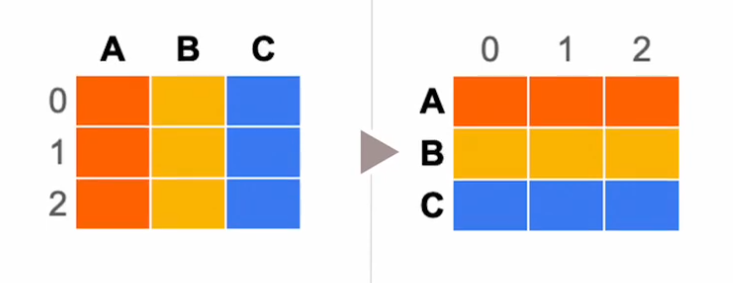

In [374]:
# 행과 열 서로 변경
# 재할당 또는 inplace=True 필요
# df.T == df.transpose()

df = df.T

print(df)

    a   b   c
가  A0  A1  A3
나  B0  B1  B3
다  c0  c1  c3


In [375]:
# 행과 열 서로 변경
# 재할당 또는 inplace=True 필요
df = df.transpose()
print(df)

    가   나   다
a  A0  B0  c0
b  A1  B1  c1
c  A3  B3  c3


### 특정 열 (column) 삭제

In [376]:
# df.drop(index, columns)
# 재할당 또는 inplace=True 필요

# 한개
df.drop(columns='나')
df.drop(columns=['나']) # 리스트도 가능

# 여러개 동시 가능
df.drop(columns=['가', '다'])

,나
a,B0
b,B1
c,B3


### 특정 행(row) 삭제

In [377]:
# df.drop(index, columns)
# 재할당 또는 inplace=True 필요

# 한개
df.drop(index='a')
df.drop(index=['a']) # 리스트도 가능

# 여러 동시 가능
df.drop(index=['a','c'])

,가,나,다
b,A1,B1,c1


### 특정 조건에 만족하는 행

In [378]:
data = {
  'name': ['joy', 'sadness', 'anger', 'fear'],
  'age': [21, 34, 43, 53],
  'salary': [5000, 6000, 7000, 8000]
}
df = pd.DataFrame(data)

df

,name,age,salary
0,joy,21,5000
1,sadness,34,6000
2,anger,43,7000
3,fear,53,8000


In [379]:
df['salary']

0    5000
1    6000
2    7000
3    8000
Name: salary, dtype: int64

In [380]:
df['salary'] < 7300

0     True
1     True
2     True
3    False
Name: salary, dtype: bool

In [381]:
# 데이터프레임의 행을 제외하고 포함시키는 메소드 (.loc[])
# 행 필터링은 재할당 필요

df.loc[[True, True, True, False]]

,name,age,salary
0,joy,21,5000
1,sadness,34,6000
2,anger,43,7000


In [382]:
df.loc[df['salary'] < 7300]

,name,age,salary
0,joy,21,5000
1,sadness,34,6000
2,anger,43,7000


In [383]:
# 값 수정
df.loc[2, 'name'] = 'envy'
df

,name,age,salary
0,joy,21,5000
1,sadness,34,6000
2,envy,43,7000
3,fear,53,8000


### 가로 합치기 - 공통 열(column) 기준

In [384]:
df1 = pd.DataFrame({
  'A': [1,2,3],
  'B': [4,5,6]
})
df2 = pd.DataFrame({
  'A': [1,2,4],
  'C': [7,8,9],
  'D': [10,11,12]
})
display(df1)
display(df2)

,A,B
0,1,4
1,2,5
2,3,6


,A,C,D
0,1,7,10
1,2,8,11
2,4,9,12


In [385]:
# pd.merge(left, right, on='공통열')

pd.merge(left=df1, right=df2, on='A')
# pd.merge(df1, df2, on='A')              # inner (기본) — 교집합만
# pd.merge(df1, df2, on='A', how='left')  # left  — df1 기준, df2에 없으면 NaN
# pd.merge(df1, df2, on='A', how='right') # right — df2 기준, df1에 없으면 NaN
# pd.merge(df1, df2, on='A', how='outer') # outer — 합집합, 없는 쪽은 NaN

,A,B,C,D
0,1,4,7,10
1,2,5,8,11


### 열 (column) 추가

In [386]:
data = {
    'Name': ['joy', 'sadness', 'anger', 'fear'],
    'Age': [21, 34, 43, 53],
}
df = pd.DataFrame(data)
display(df)

,Name,Age
0,joy,21
1,sadness,34
2,anger,43
3,fear,53


In [387]:
# 새로운 열로 추가 가능 : 리스트, 튜플, pandas series, numpy 배열 등
df['Gender'] = ['F', 'M', 'F', 'M']
display(df)

,Name,Age,Gender
0,joy,21,F
1,sadness,34,M
2,anger,43,F
3,fear,53,M


In [388]:
li_full_gender = []

for gender in df['Gender']:
  if gender == 'F':
    li_full_gender.append('Female')
  else:
    li_full_gender.append('Male')

print(li_full_gender)

['Female', 'Male', 'Female', 'Male']


In [389]:
df['Full_Gender'] = li_full_gender

df

,Name,Age,Gender,Full_Gender
0,joy,21,F,Female
1,sadness,34,M,Male
2,anger,43,F,Female
3,fear,53,M,Male


In [390]:
df['Check'] = True
df

,Name,Age,Gender,Full_Gender,Check
0,joy,21,F,Female,True
1,sadness,34,M,Male,True
2,anger,43,F,Female,True
3,fear,53,M,Male,True


### 행 (row) 추가

In [391]:
data = {
    'Name': ['joy', 'sadness', 'anger', 'fear'],
    'Age': [21, 34, 43, 53],
}
df = pd.DataFrame(data)
display(df)
new_data = {'Name': ['envy'], 'Age': [49]}
new_df = pd.DataFrame(new_data)
display(new_df)

,Name,Age
0,joy,21
1,sadness,34
2,anger,43
3,fear,53


,Name,Age
0,envy,49


In [392]:
# 세로 방향으로 합치는 함수
# append() == concat()

df.append(new_df)

/var/folders/56/l105m02x5593bbj0j1dsv0xc0000gn/T/ipykernel_40570/3357002040.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df.append(new_df)


,Name,Age
0,joy,21
1,sadness,34
2,anger,43
3,fear,53
0,envy,49


In [393]:
# index

df.append(new_df).reset_index()

/var/folders/56/l105m02x5593bbj0j1dsv0xc0000gn/T/ipykernel_40570/2131859805.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df.append(new_df).reset_index()


,index,Name,Age
0,0,joy,21
1,1,sadness,34
2,2,anger,43
3,3,fear,53
4,0,envy,49


In [394]:
# index (필요없는 행 없애기)

df.append(new_df).reset_index(drop=True)

/var/folders/56/l105m02x5593bbj0j1dsv0xc0000gn/T/ipykernel_40570/607664678.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df.append(new_df).reset_index(drop=True)


,Name,Age
0,joy,21
1,sadness,34
2,anger,43
3,fear,53
4,envy,49


In [395]:
pd.concat([df, new_df])

,Name,Age
0,joy,21
1,sadness,34
2,anger,43
3,fear,53
0,envy,49


In [396]:
pd.concat([df, new_df]).reset_index(drop=True)

,Name,Age
0,joy,21
1,sadness,34
2,anger,43
3,fear,53
4,envy,49


### 데이터프레임 셀 값 세로로 쌓기

In [397]:
data = {
    'Name': ['joy', 'sadness', 'anger', 'fear'],
    'Age': [21, 34, 43, 53],
    'Gender': ['F', 'F', 'M', 'M']
}
df = pd.DataFrame(data)
df

,Name,Age,Gender
0,joy,21,F
1,sadness,34,F
2,anger,43,M
3,fear,53,M


In [398]:
# 멀티 인덱스 & 다중 인덱스
# 셀 값들은 셀 값 그대로 인덱스도 그대로
# 열 (컬럼명) -> 인덱스 일종으로 변환
df.stack()

0  Name          joy
   Age            21
   Gender          F
1  Name      sadness
   Age            34
   Gender          F
2  Name        anger
   Age            43
   Gender          M
3  Name         fear
   Age            53
   Gender          M
dtype: object

### 다중 인덱스 생성

In [399]:
data = [[1, 2, 3, 4],
        [5, 6, 7, 8],
        [9, 10, 11, 12],
        [13, 14, 15, 16]
       ]
df = pd.DataFrame(data)
df

,0,1,2,3
0,1,2,3,4
1,5,6,7,8
2,9,10,11,12
3,13,14,15,16


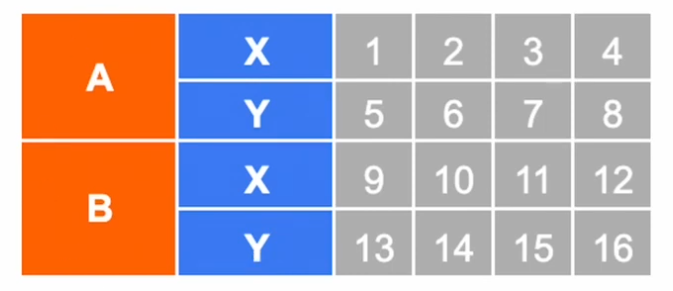

In [400]:

my_index = pd.MultiIndex.from_product([['A', 'B'], ['X', 'Y']])
print(my_index)

MultiIndex([('A', 'X'),
            ('A', 'Y'),
            ('B', 'X'),
            ('B', 'Y')],
           )


In [401]:
df = pd.DataFrame(data, index = my_index)
df

0   1   2   3
A X   1   2   3   4
  Y   5   6   7   8
B X   9  10  11  12
  Y  13  14  15  16

In [402]:
my_index = pd.MultiIndex.from_tuples([
    ('A', 'a'), ('A', 'b'),
    ('B', 'c'), ('B', 'd')
])
df = pd.DataFrame(data, index=my_index)
df

0   1   2   3
A a   1   2   3   4
  b   5   6   7   8
B c   9  10  11  12
  d  13  14  15  16

### 다중 인덱스에 이름 생성

In [403]:
# 인덱스 = Level (인덱스 계층의 이름) + Label (인덱스 값)

my_index = pd.MultiIndex.from_product(
  [['A', 'B'], ['x', 'y']],
  names = ['Upper', 'Lower']
  )
df = pd.DataFrame(data, index=my_index)
df


0   1   2   3
Upper Lower                
A     x       1   2   3   4
      y       5   6   7   8
B     x       9  10  11  12
      y      13  14  15  16

### n번째 행/열 iloc 선택

In [404]:
data = [['00', '01', '02', '03'],
        ['10', '11', '12', '13'],
        ['20', '21', '22', '23'],
        ['30', '31', '32', '33']
       ]
df = pd.DataFrame(data)
df

,0,1,2,3
0,00,01,02,03
1,10,11,12,13
2,20,21,22,23
3,30,31,32,33


In [405]:
df = df.rename(
    index = {0 : 'A', 1 : 'B', 2 : 'C', 3 : 'D'},
    columns = {0 : '가', 1 : '나', 2 : '다', 3 : '라'}
)
df

,가,나,다,라
A,00,01,02,03
B,10,11,12,13
C,20,21,22,23
D,30,31,32,33


In [406]:
# .iloc[] -> 선택하고자 하는 행의 위치 (i == integer)
# df.iloc['선택할 행의 위치' , '선택할 열의 위치']
# df.iloc[['선택할 행의 위치'] , ['선택할 열의 위치']]

print(df.iloc[0,0])  # 0행 0열 단일 값 → 스칼라 반환 (단일 값)
print()
print(df.iloc[[0],[0]]) # 0행 0열 → DataFrame 반환 (리스트로 감싸면 DataFrame 유지)
print()
print(df.iloc[[0],[0,1,2,3]]) # 0행, 0~3열 → DataFrame 반환
print()
print(df.iloc[[0],:]) # 0행, 모든 열 → DataFrame 반환
print()
print(df.iloc[:,[2]]) # 모든 행, 2열 → DataFrame 반환
print()
print(df.iloc[[2,3]]) # 2~3행, 모든 열 (열 생략 시 전체 열 선택) → DataFrame 반환
print()
print(df.iloc[2]) # 2행 → Series 반환 (리스트 없이 정수만 넣으면 Series)




00

    가
A  00

    가   나   다   라
A  00  01  02  03

    가   나   다   라
A  00  01  02  03

    다
A  02
B  12
C  22
D  32

    가   나   다   라
C  20  21  22  23
D  30  31  32  33

가    20
나    21
다    22
라    23
Name: C, dtype: object


### 행/열 이름으로 loc 선택

In [ ]:
# df.loc['선택할 행의 라벨', '선택할 열의 라벨']
# df.loc[['선택할 행의 라벨'], ['선택할 열의 라벨']]
print(df)
print()
print(df.loc[['B','C'], ['나', '다']]) # B,C행 + 나,다열
print()
print(df.loc[['B','C'], :]) # B,C행 + 모든 열
print()
print(df.loc[:, ['나', '다']]) # 모든 행 + 나,다열
print()
print(df.loc[['B', 'C']]) # B,C행 + 모든 열 (열 생략 시 전체)
print()
print(df[['나', '다']]) # 나,다열 + 모든 행 (열 선택 단축 문법)

    가   나   다   라
A  00  01  02  03
B  10  11  12  13
C  20  21  22  23
D  30  31  32  33

    나   다
B  11  12
C  21  22

    가   나   다   라
B  10  11  12  13
C  20  21  22  23

    나   다
A  01  02
B  11  12
C  21  22
D  31  32

    가   나   다   라
B  10  11  12  13
C  20  21  22  23

    나   다
A  01  02
B  11  12
C  21  22
D  31  32


### 특정 문자열 포함한 행 선택

In [409]:
data = {
'C1': [1, 2, 3, 4, 5],
'C2': [6, 7, 8, 9, 10],
'C3': ['XYZ', 'ABC', 'DEF', 'ABCD', 'LMNABC'],
'C4': ['GHI', 'JKL', 'MNO', 'PQR', 'STU'],
'C5': ['MNO', 'STU', 'VWXY', 'Z', 'UVW']
}
df = pd.DataFrame(data)
df

,C1,C2,C3,C4,C5
0,1,6,XYZ,GHI,MNO
1,2,7,ABC,JKL,STU
2,3,8,DEF,MNO,VWXY
3,4,9,ABCD,PQR,Z
4,5,10,LMNABC,STU,UVW


In [414]:
# df.loc['행을 선택하는 수식이나 조건 -> True/False 배열']

print(df['C3'])
print()
print(df['C3'].str.contains('ABC'))
print()
print(df[df['C3'].str.contains('ABC')])

0       XYZ
1       ABC
2       DEF
3      ABCD
4    LMNABC
Name: C3, dtype: object

0    False
1     True
2    False
3     True
4     True
Name: C3, dtype: bool

   C1  C2      C3   C4   C5
1   2   7     ABC  JKL  STU
3   4   9    ABCD  PQR    Z
4   5  10  LMNABC  STU  UVW


In [417]:
# 함수
li_boolean = []

for element in df['C3'] :
  if 'ABC' in element :
    li_boolean.append(True)
  else :
    li_boolean.append(False)
df.loc[li_boolean]

,C1,C2,C3,C4,C5
1,2,7,ABC,JKL,STU
3,4,9,ABCD,PQR,Z
4,5,10,LMNABC,STU,UVW


### 결측값(Nan, None) 포함한 행 제거

In [419]:
import pandas as pd
data = {'A': [1, 2, None, 4],
        'B': [5, None, 7, 8],
        'C': ['a', 'b', None, 'd']}
df = pd.DataFrame(data)
df

,A,B,C
0,1.0,5.0,a
1,2.0,NaN,b
2,NaN,7.0,None
3,4.0,8.0,d


In [420]:
df.dropna()

,A,B,C
0,1.0,5.0,a
3,4.0,8.0,d


In [422]:
df.dropna(subset = ['B']) # NaN/None 제외하고 싶은 열

,A,B,C
0,1.0,5.0,a
2,NaN,7.0,None
3,4.0,8.0,d


### loc vs iloc

In [ ]:
data = [
    [0, 1, 2, 3],
    [4, 5, 6, 7],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
]
df = pd.DataFrame(data)
df

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,9,10,11,12
3,13,14,15,16


In [426]:
# 공통점: Boolean Indexing
indexing_boolean = [True, False, True, False]
print(df.iloc[indexing_boolean])
print()
print(df.loc[indexing_boolean])


   0   1   2   3
0  0   1   2   3
2  9  10  11  12

   0   1   2   3
0  0   1   2   3
2  9  10  11  12


In [ ]:
# 차이점

df = df.rename(index = {
    0:'A', 1:'B', 2:'C', 3:'D'
})
print(df.loc[['A', 'C']]) # 라벨명
print()
print(df.iloc[[0, 2]]) # 라벨 위치

   0   1   2   3
A  0   1   2   3
C  9  10  11  12

   0   1   2   3
A  0   1   2   3
C  9  10  11  12
